#hej

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import seaborn as sns


## EDA
-   Datastorlek 12 000 rader, 18 kolumner
-   Datatyper: 14 numeriska och 4 kategoriska kolumner.
-   Targetfördelning: is_suspicious 10,2 %
-   Missingvalue konstaterades i två numeriska kolumner där ett missingvalue ersätts med median och en kategorisk kolumn där missingvalue hanteras som en egen kategori.
-   Data i korrelationsmatris visar ingen enskild feature som har stark linjär relation.

In [ ]:
df = pd.read_csv("historical_data.csv")

target_column_name = "is_suspicious" 
feature_column_names = [col for col in df.columns if col != target_column_name]

# Info
print("\nDataset information: ")
df.info()

numeric_features = ["id", "day", 
                    "account_age_days", "num_prev_listings", 
                    "prev_reports_30d", "verification_level",
                    "price", "num_images",
                    "message_length", "contains_off_platform",
                    "urgency_words", "payment_attempt",
                    "time_to_first_response_min", "is_suspicious"]
categorical_features = ["event_type", "category", "region", "device"]


# Target-fördelning
print(df[target_column_name].value_counts(normalize=True) * 100)


Dataset information: 
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  contains_off_platfo

is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64

In [ ]:
# Kategorisk analys

print("\nKategoriska värden:")
for col in categorical_features:
    print(f"\nKolumn: {col}")
    print(df[col].value_counts())
    print("Antal unika värden:", df[col].nunique())



Kategoriska värden:

Kolumn: event_type
event_type
ad_post         8535
message_send    3465
Name: count, dtype: int64
Antal unika värden: 2

Kolumn: category
category
other          2850
furniture      2208
electronics    2173
bikes          1922
phones         1475
fashion        1372
Name: count, dtype: int64
Antal unika värden: 6

Kolumn: region
region
metro    5219
urban    4095
rural    2346
Name: count, dtype: int64
Antal unika värden: 3

Kolumn: device
device
android    6616
ios        4160
web        1224
Name: count, dtype: int64
Antal unika värden: 3


In [ ]:
# Saknade värden

print("Missing values i hela datasetet:")
print(df.isna().sum().sort_values(ascending=False))



Missing values i hela datasetet:
price                         818
time_to_first_response_min    590
region                        340
id                              0
day                             0
event_type                      0
account_age_days                0
num_prev_listings               0
category                        0
device                          0
verification_level              0
prev_reports_30d                0
message_length                  0
num_images                      0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
is_suspicious                   0
dtype: int64


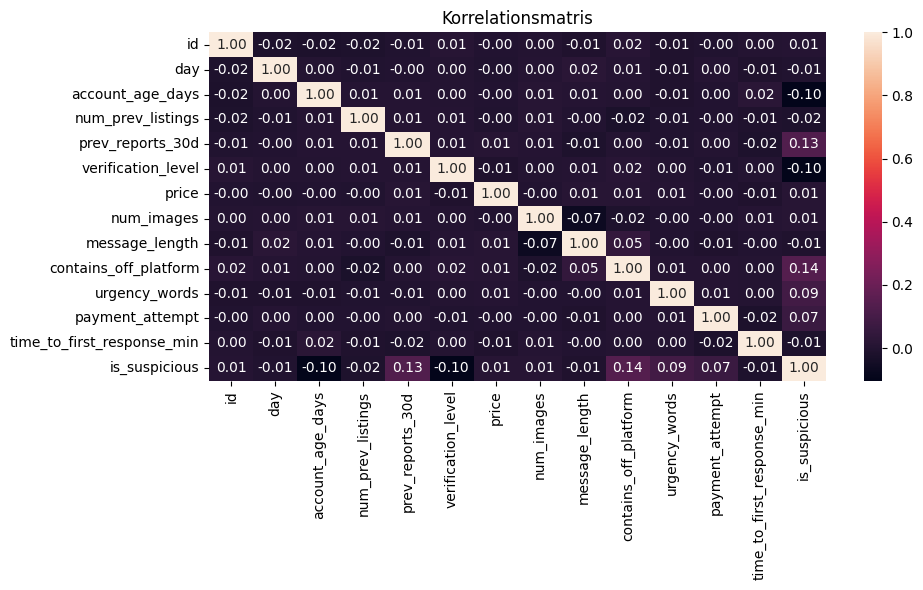

KeyError: 'target_column_name'

In [34]:
#Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", ax=ax)
ax.set_title("Korrelationsmatris")
plt.tight_layout()
plt.show()

sns.countplot(x=df["target_column_name"])